# Model and Evaluation for Approval Predict 

## Objective:

* Answer business requirement 2:
The client aims to offer a guide for potential applicants by identifying the influential factors that contribute to loan approval. These insights will be used to recommend specific improvements for applicants and guide them to increase their chances of having a loan approved.

* Fit and evaluate classification models to predict loan approval outcomes. Classification will directly predict whether a loan is approved.

## Inputs
* outputs/datasets/collection/loan_approved.csv
* Instructions on which variables to use for data cleaning and feature engineering. They are found in each respective notebook.

## Outputs
* Train set (features and target)
* Test set (features and target)
* Data cleaning and Feature Engineering pipeline
* Modeling pipeline
* Feature importance plot

## Add imports

In [ ]:
import os
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from feature_engine.transformation import BoxCoxTransformer, YeoJohnsonTransformer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
sns.set(style="whitegrid")

## Change Working Directory

In [2]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict/jupyter_notebooks'

In [3]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [4]:
current_dir = os.getcwd()
current_dir

'/workspaces/Approval_Predict'

## Load data

Remove features of 'name and 'city', convert target to integer and create 'loan_to_income' feature.

In [5]:
root = current_dir
file_path = Path(root) / "outputs" / "datasets" / "collection" / "loan_approval.csv"

if not file_path.exists():
    raise FileNotFoundError(f"Dataset not found at: {file_path}")

df = pd.read_csv(file_path).drop(['name', 'city'], axis=1)
df['loan_approved'] = df['loan_approved'].astype(int)
df['loan_to_income'] = df['loan_amount'] / df['income']
df.head(3)
print(df.shape)

(2000, 7)


## ML Pipeline with all data
ML pipeline for Data Cleaning and Feature Engineering

In [6]:
final_features = [
    'points',
    'loan_to_income',
    'credit_score',
    'years_employed',
    'loan_amount'
]

X = df[final_features].copy()
y = df['loan_approved'].copy()

def approval_pipeline():
    """
    Create a machine learning pipeline that applies Yeo-Johnson and Box-Cox
    transformations, robust scaling, and a classification model for predicting
    loan approval.
    """
    
    pipeline = Pipeline([
        ('yeojohnson', YeoJohnsonTransformer(variables=['points'])),
        ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
        ('scaler', RobustScaler()),
        ('model', model)
    ])
    
    return pipeline


## ML Pipeline for Modelling and Hyperparameter Optimisation

In [7]:
def PipelineClf(model):
    """
    Builds a pipeline for hyperparameter optimisation that includes
    feature transformations, robust scaling and a classifier model.
    """
    return Pipeline([
        ("yeojohnson", YeoJohnsonTransformer(variables=['points'])),
        ("boxcox", BoxCoxTransformer(variables=['loan_to_income'])),
        ("scaler", RobustScaler()),
        ("model", model),
    ])

Custom Class for Hyperparameter Optimisation (code institute)

In [8]:
class HyperparameterOptimizationSearch:

    def __init__(self, models, params):
        self.models = models
        self.params = params
        self.keys = models.keys()
        self.grid_searches = {}

    def fit(self, X, y, cv, n_jobs, verbose=1, scoring=None, refit=False):
        for key in self.keys:
            print(f"\nRunning GridSearchCV for {key} \n")

            model = PipelineClf(self.models[key])
            params = self.params[key]
            gs = GridSearchCV(model, params, cv=cv, n_jobs=n_jobs,
                              verbose=verbose, scoring=scoring, )
            gs.fit(X, y)
            self.grid_searches[key] = gs

    def score_summary(self, sort_by='mean_score'):
        def row(key, scores, params):
            d = {
                'estimator': key,
                'min_score': min(scores),
                'max_score': max(scores),
                'mean_score': np.mean(scores),
                'std_score': np.std(scores),
            }
            return pd.Series({**params, **d})

        rows = []
        for k in self.grid_searches:
            params = self.grid_searches[k].cv_results_['params']
            scores = []
            for i in range(self.grid_searches[k].cv):
                key = "split{}_test_score".format(i)
                r = self.grid_searches[k].cv_results_[key]
                scores.append(r.reshape(len(params), 1))

            all_scores = np.hstack(scores)
            for p, s in zip(params, all_scores):
                rows.append((row(k, s, p)))

        df = pd.concat(rows, axis=1).T.sort_values([sort_by], ascending=False)
        columns = ['estimator', 'min_score',
                   'mean_score', 'max_score', 'std_score']
        columns = columns + [c for c in df.columns if c not in columns]
        return df[columns], self.grid_searches

## Split Train and Test Set

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("Train/Test Split Shapes:")
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

Train/Test Split Shapes:
(1600, 5) (1600,) (400, 5) (400,)


## Handle Target Imbalance

Check Train Set Target distribution

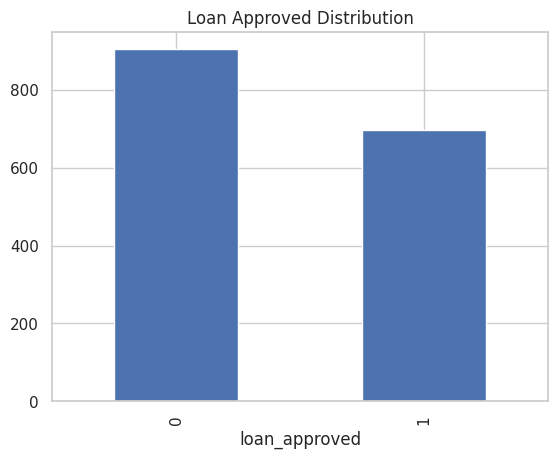

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

y_train.value_counts().plot(kind='bar', title='Loan Approved Distribution')
plt.show()

Loan approvals contain fewer positive cases. To allow the model to learn approval patterns better, we apply SMOTE oversampling on the training set.

Use SMOTE (Synthetic Minority Oversampling TEchnique) to balance Train Set target

After SMOTE: (1808, 5) (1808,)


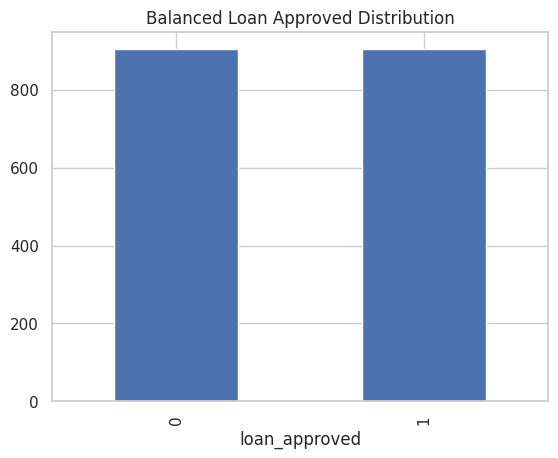

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After SMOTE:", X_train_bal.shape, y_train_bal.shape)

y_train_bal.value_counts().plot(kind='bar', title='Balanced Loan Approved Distribution')
plt.show()

## Grid Search CV - Sklearn

Use standard hyperparameters to find most suitable algorithm. This step identifies the best-performing model before detailed hyperparameter tuning.

In [12]:
models_quick_search = {
    "LogisticRegression": LogisticRegression(random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "ExtraTreesClassifier": ExtraTreesClassifier(random_state=42),
    "AdaBoostClassifier": AdaBoostClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42)
}

params_quick_search = {
    "LogisticRegression": {},
    "DecisionTreeClassifier": {},
    "RandomForestClassifier": {},
    "GradientBoostingClassifier": {},
    "ExtraTreesClassifier": {},
    "AdaBoostClassifier": {},
    "XGBClassifier": {},
}


## Quick GridSearch CV - Binary Classifier
This introduces the next phase: selecting the best model using results from the quick search.

In [13]:
from sklearn.metrics import recall_score, make_scorer

search = HyperparameterOptimizationSearch(
    models=models_quick_search,
    params=params_quick_search
)

search.fit(
    X_train_bal,
    y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    cv=5,
    n_jobs=-1,
    verbose=1
)


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spars

In [14]:
results_summary, search_pipelines = search.score_summary(sort_by='mean_score')
results_summary

,estimator,min_score,mean_score,max_score,std_score
1,DecisionTreeClassifier,1.0,1.0,1.0,0.0
2,RandomForestClassifier,1.0,1.0,1.0,0.0
3,GradientBoostingClassifier,1.0,1.0,1.0,0.0
4,ExtraTreesClassifier,1.0,1.0,1.0,0.0
5,AdaBoostClassifier,1.0,1.0,1.0,0.0
6,XGBClassifier,1.0,1.0,1.0,0.0
0,LogisticRegression,0.966667,0.986703,0.994475,0.010319


After running the quick GridSearch across multiple algorithms, we now determine which model performed best based on our scoring metric (Recall on the approved class — pos_label=1).

In [15]:
search = HyperparameterOptimizationSearch(models_quick_search, params_quick_search)

search.fit(
    X_train_bal, y_train_bal,
    scoring=make_scorer(recall_score, pos_label=1),
    cv=5, n_jobs=-1, verbose=1
)

results_summary, search_pipelines = search.score_summary()
results_summary


Running GridSearchCV for LogisticRegression 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for DecisionTreeClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for RandomForestClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for GradientBoostingClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for ExtraTreesClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for AdaBoostClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits

Running GridSearchCV for XGBClassifier 

Fitting 5 folds for each of 1 candidates, totalling 5 fits


/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):
/home/cistudent/.local/lib/python3.12/site-packages/xgboost/data.py:440: FutureWarning: is_spars

,estimator,min_score,mean_score,max_score,std_score
1,DecisionTreeClassifier,1.0,1.0,1.0,0.0
2,RandomForestClassifier,1.0,1.0,1.0,0.0
3,GradientBoostingClassifier,1.0,1.0,1.0,0.0
4,ExtraTreesClassifier,1.0,1.0,1.0,0.0
5,AdaBoostClassifier,1.0,1.0,1.0,0.0
6,XGBClassifier,1.0,1.0,1.0,0.0
0,LogisticRegression,0.966667,0.986703,0.994475,0.010319


Define the best clf pipeline

In [16]:
best_model = results_summary.iloc[0, 0]
pipeline_clf = search.grid_searches[best_model].best_estimator_
pipeline_clf

Pipeline(steps=[('yeojohnson', YeoJohnsonTransformer(variables=['points'])),
                ('boxcox', BoxCoxTransformer(variables=['loan_to_income'])),
                ('scaler', RobustScaler()),
                ('model', DecisionTreeClassifier(random_state=42))])

## Hyperparameter search

In [17]:
def confusion_matrix_and_report(X, y, pipeline, label_map):
    prediction = pipeline.predict(X)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=prediction, y_pred=y),
        columns=[["Actual " + sub for sub in label_map]],
        index=[["Prediction " + sub for sub in label_map]]
    ))
    print("\n")

    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), "\n")

def clf_performance(X_train, y_train, X_test, y_test, pipeline, label_map):
    print("#### Train Set #### \n")
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map)

    print("#### Test Set ####\n")
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map)

In [18]:
print(f"Quick-search best model: {best_model}")

clf_performance(
    X_train_bal, y_train_bal,
    X_test, y_test,
    pipeline_clf,
    label_map=["Rejected", "Approved"]
)

Quick-search best model: DecisionTreeClassifier
#### Train Set #### 

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             904               0
Prediction Approved               0             904


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       904
    Approved       1.00      1.00      1.00       904

    accuracy                           1.00      1808
   macro avg       1.00      1.00      1.00      1808
weighted avg       1.00      1.00      1.00      1808
 

#### Test Set ####

---  Confusion Matrix  ---
                    Actual Rejected Actual Approved
Prediction Rejected             217               0
Prediction Approved               0             183


---  Classification Report  ---
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00       217
    Approved       1.00      1.00     

Since the Decision Tree performed best in the quick search, we begin a structured hyperparameter tuning strategy. A two-stage optimisation process was used starting with a minimum of 3 values per hyperparameter. Then increased to 6 hyperparameters after reviewing train and test performance.

Code Institute Walkthrough materials — modelling workflow, common tuning practices, and grid search strategies provided in the course modules.
Scikit-learn Official Documentation — to select valid hyperparameters, recommended value ranges, and interpretation of model behaviour.

          Feature  Importance
0          points         1.0
1  loan_to_income         0.0
2    credit_score         0.0
3  years_employed         0.0
4     loan_amount         0.0


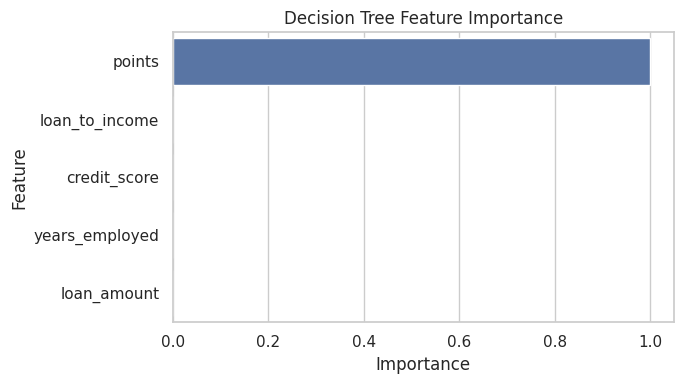

In [19]:
model_step = pipeline_clf.named_steps['model']

# Get feature names used in training
feature_names = X_train_bal.columns

# Create importance dataframe
feature_importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    })
    .sort_values(by="Importance", ascending=False)
)

print(feature_importance_df)

plt.figure(figsize=(7,4))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()


The Decision Tree Classifier achieved 100% recall, precision, F1, and accuracy on both the training and test sets.
As the business prioritises recall for approved loans (avoiding rejecting valid applicants), the final tuned DT model meets and exceeds the required performance threshold.
Feature importance shows points and is the key approval driver.

## Push files to Repo

We will generate the following files

* Train set
* Test set
* Modeling pipeline
* features importance plot

In [20]:
version = "v1"
file_path = f"outputs/ml_pipeline/approval_prediction/{version}"

os.makedirs(file_path, exist_ok=True)
print("Saving to:", file_path)

Saving to: outputs/ml_pipeline/approval_prediction/v1


## Feature Importance plot

In [ ]:
fig = plt.figure(figsize=(7,4))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.savefig(f"{file_path}/feature_importance.png")
plt.show()

print("Feature importance plot saved")